# EDA — Transacciones
Análisis profundo de `transactions.csv` + `transactions_v2.csv`.
Cubre: precios, planes, descuentos, cancelaciones y comparación churn vs renewal.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.eda.transactions_02 import (
    load_transactions, load_train_labels,
    analyze_tx_patterns, build_user_features, analyze_churn_vs_renewal,
    plot_plan_days_distribution, plot_price_distribution,
    plot_churn_comparisons, plot_cancel_and_autorenew_churn, plot_price_trend_churn,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Carga y overview general

In [2]:
tx = load_transactions()
tx_results = analyze_tx_patterns(tx)

═══════════════════════════════════════════════════════
TRANSACTIONS — overview
  shape            : (22978755, 11)
  usuarios únicos  : 2,426,143
  rango fechas     : 2015-01-01 → 2017-03-31
  descuento medio  : 2.9%
  precio=0 (free)  : 6.6%
  auto-renew rate  : 84.8%
  cancel rate      : 3.9%

  Distribución payment_plan_days (top 10):
       0 días :    872,342
       7 días :    589,807
      10 días :     38,632
      30 días : 20,174,288
      31 días :    766,612
      90 días :     31,440
     100 días :     28,252
     180 días :     76,172
     195 días :    138,802
     410 días :    162,236


## 2. Distribución de planes y precios

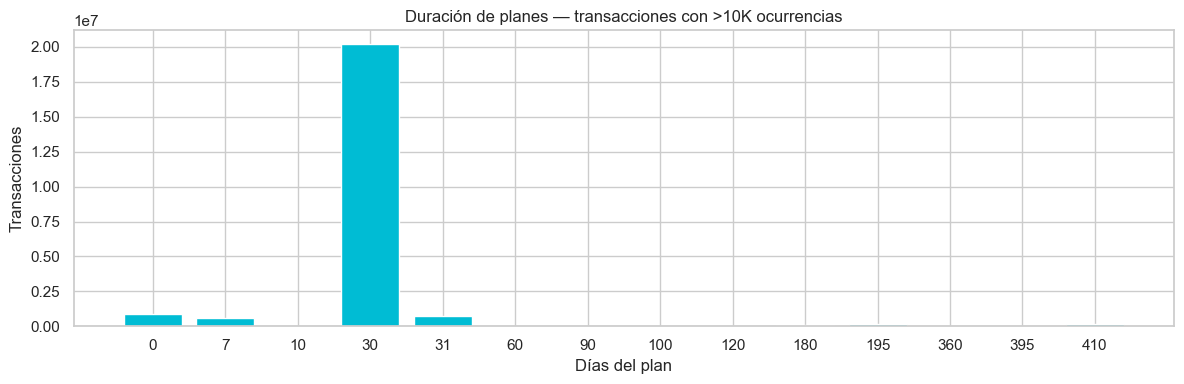

In [3]:
plot_plan_days_distribution(tx)

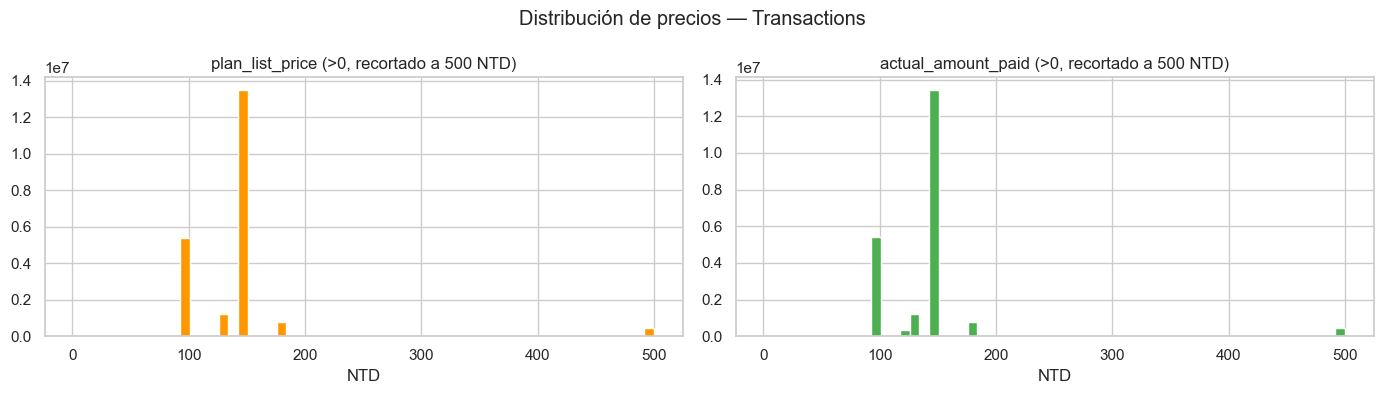

In [4]:
plot_price_distribution(tx)

In [5]:
# Precio 0 — free trials o promociones
free = tx[tx['plan_list_price'] == 0]
print(f"Transacciones con precio=0 : {len(free):,} ({len(free)/len(tx):.1%})")
print(f"Usuarios únicos con precio=0: {free['msno'].nunique():,}")
print(f"\nDistribución payment_plan_days en precio=0:")
print(free['payment_plan_days'].value_counts().head(10))

Transacciones con precio=0 : 1,516,957 (6.6%)
Usuarios únicos con precio=0: 1,032,230

Distribución payment_plan_days en precio=0:
payment_plan_days
0      872342
7      582075
10      37579
14       6186
1        5435
60       2506
240      1946
30       1688
410      1625
195      1171
Name: count, dtype: int64


## 3. Features por usuario

In [6]:
user_feats = build_user_features(tx)
print(f"Shape: {user_feats.shape}")
user_feats.describe()

Shape: (2426143, 16)


,n_transactions,n_cancels,ever_canceled,avg_discount_pct,avg_plan_days,avg_price,n_unique_plans,n_payment_methods,last_is_cancel,last_is_auto_renew,last_plan_days,last_price,last_list_price,price_trend,last_payment_method
count,2.426143e+06,2.426143e+06,2.426143e+06,2.022548e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06,2.426143e+06
mean,9.471311e+00,3.676552e-01,3.274271e-01,1.216621e-01,4.574671e+01,1.854560e+02,1.446909e+00,1.195647e+00,2.107901e-01,5.859593e-01,5.104924e+01,2.043506e+02,2.164319e+02,2.574437e+01,3.741915e+01
std,9.294885e+00,5.772337e-01,4.692746e-01,3.137163e-01,7.471082e+01,3.284731e+02,7.281820e-01,4.931950e-01,4.078697e-01,4.925557e-01,8.866221e+01,3.851175e+02,3.791507e+02,2.594492e+02,4.517466e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,-8.859358e-02,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.000000e+03,1.000000e+00
25%,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.700000e+01,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,9.900000e+01,0.000000e+00,3.500000e+01
50%,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,1.298462e+02,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+01,1.290000e+02,1.490000e+02,0.000000e+00,3.800000e+01
75%,1.600000e+01,1.000000e+00,1.000000e+00,0.000000e+00,3.000000e+01,1.490000e+02,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+01,1.490000e+02,1.490000e+02,0.000000e+00,4.100000e+01
max,2.440000e+02,2.100000e+01,1.000000e+00,1.000000e+00,4.500000e+02,2.000000e+03,9.000000e+00,9.000000e+00,1.000000e+00,1.000000e+00,4.500000e+02,2.000000e+03,2.000000e+03,2.000000e+03,4.100000e+01


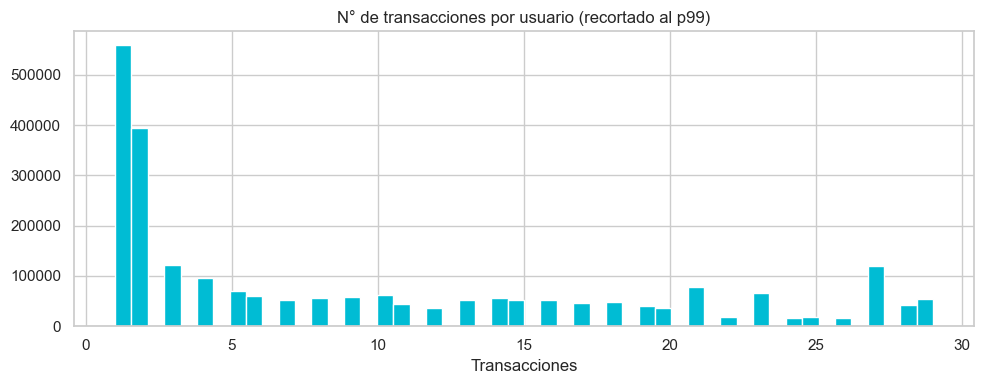

In [7]:
# Distribución de n_transactions por usuario
fig, ax = plt.subplots(figsize=(10, 4))
user_feats['n_transactions'].clip(upper=user_feats['n_transactions'].quantile(0.99)).hist(
    bins=50, ax=ax, color='#00BCD4', edgecolor='white'
)
ax.set_title('N° de transacciones por usuario (recortado al p99)')
ax.set_xlabel('Transacciones')
plt.tight_layout()
plt.show()

## 4. Churn vs Renewal — comparación de features

In [8]:
labels = load_train_labels()
df_labeled = analyze_churn_vs_renewal(user_feats, labels)

═══════════════════════════════════════════════════════
CHURN vs RENEWAL — diferencias en features de transacciones
  usuarios en análisis: 992,931
  churn rate          : 6.39%

                    Renewal (0)   Churn (1)  diff_%
n_transactions        17.527521   11.444187   -34.7
n_cancels              0.287601    0.624395   117.1
ever_canceled          0.231661    0.488617   110.9
avg_discount_pct       0.006749    0.016721   147.8
avg_plan_days         31.660216   62.688546    98.0
avg_price            138.906645  272.735037    96.3
last_is_cancel         0.021868    0.392872  1696.6
last_is_auto_renew     0.919124    0.423028   -54.0
last_plan_days        32.884742   71.077831   116.1
last_price           140.391365  304.659151   117.0
price_trend           -2.429771   40.526319  1767.9


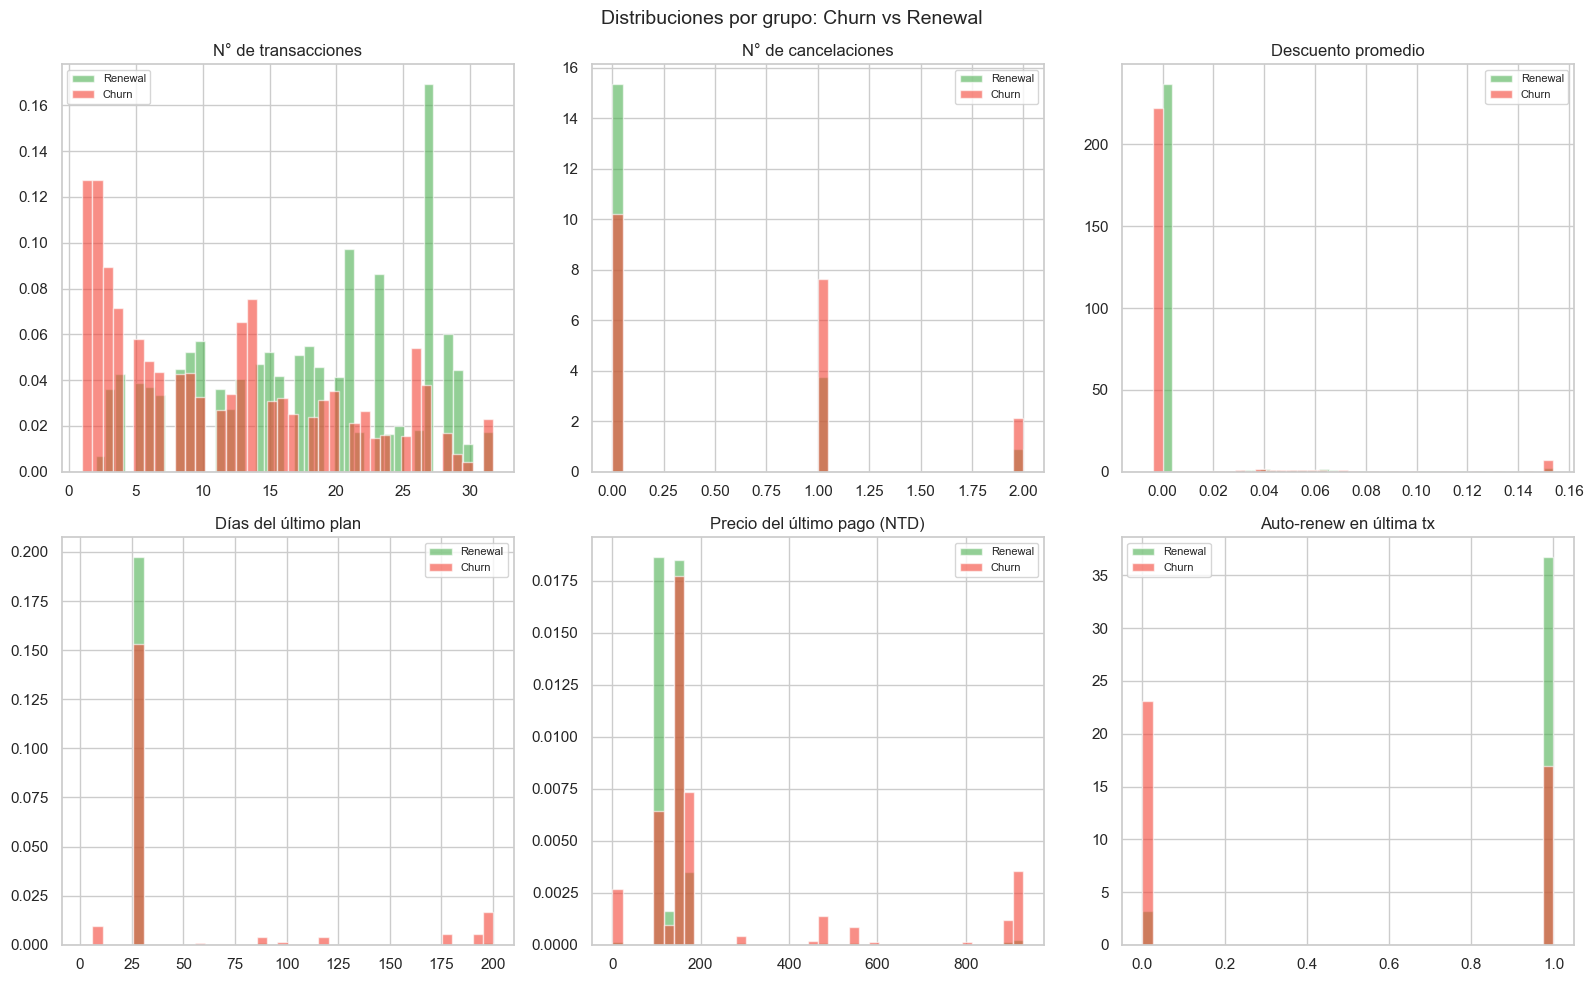

In [9]:
plot_churn_comparisons(df_labeled)

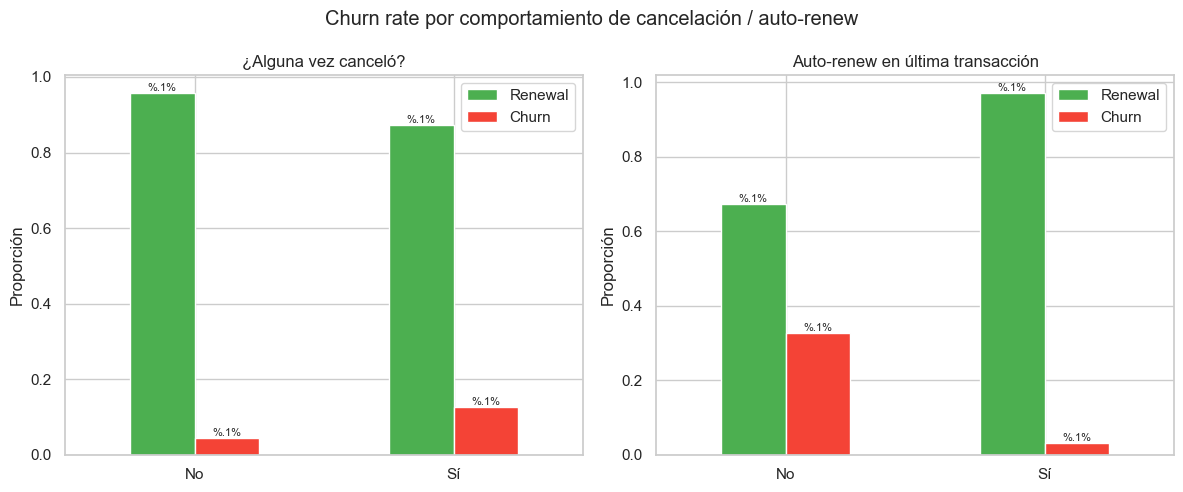

In [10]:
plot_cancel_and_autorenew_churn(df_labeled)

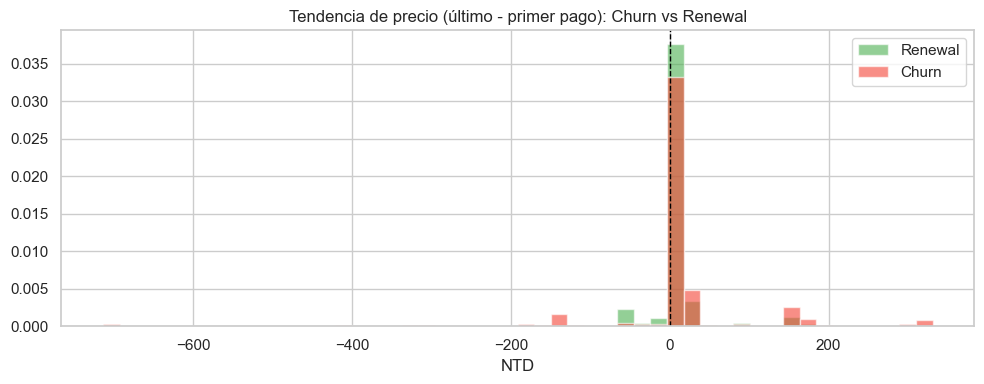

In [11]:
plot_price_trend_churn(df_labeled)

## 5. Churn rate por tipo de plan

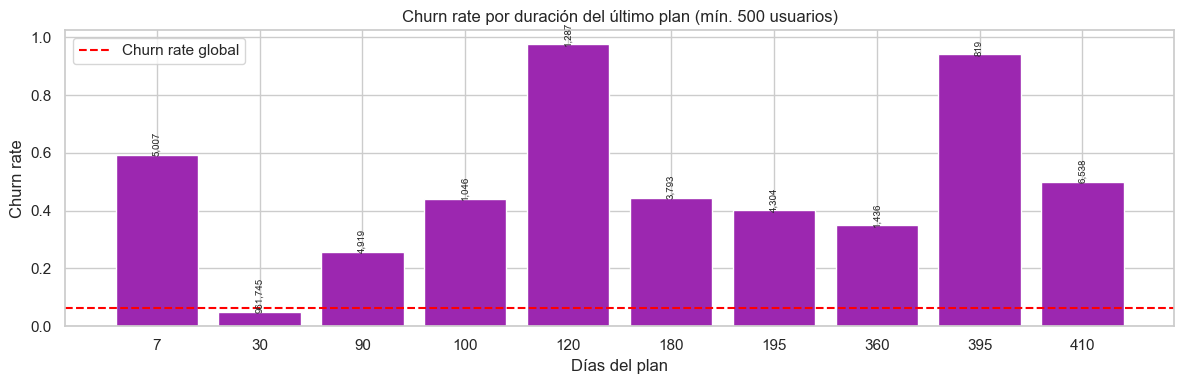

In [12]:
plan_churn = df_labeled.groupby('last_plan_days')['is_churn'].agg(['mean', 'count']).reset_index()
plan_churn.columns = ['last_plan_days', 'churn_rate', 'n_users']
plan_churn = plan_churn[plan_churn['n_users'] >= 500].sort_values('last_plan_days')

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(plan_churn['last_plan_days'].astype(str), plan_churn['churn_rate'],
              color='#9C27B0', edgecolor='white')
ax.axhline(df_labeled['is_churn'].mean(), color='red', linestyle='--', label='Churn rate global')
ax.set_title('Churn rate por duración del último plan (mín. 500 usuarios)')
ax.set_xlabel('Días del plan')
ax.set_ylabel('Churn rate')
ax.legend()
for bar, row in zip(bars, plan_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{row.n_users:,}', ha='center', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig('../reports/figures/tx_churn_by_plan_days.png', dpi=150)
plt.show()

## 6. Churn rate por método de pago

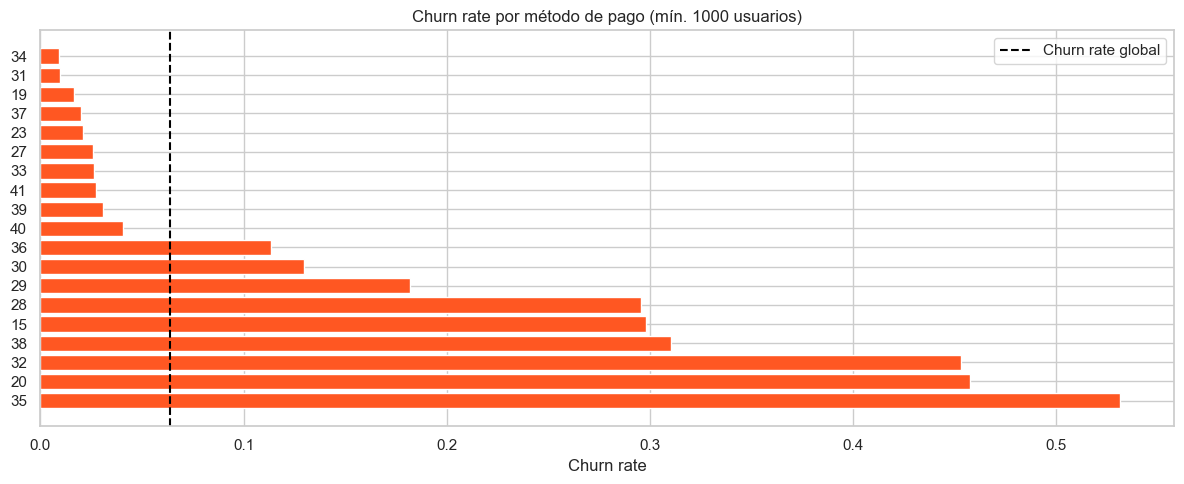

 payment_method  churn_rate  n_users
             35    0.531375     4255
             20    0.457602     1368
             32    0.453252    11316
             38    0.310236    55996
             15    0.297982     2131
             28    0.295863     2224
             29    0.181864    15957
             30    0.129826    16784
             36    0.113302    70405
             40    0.040816    74849
             39    0.030637    64922
             41    0.027394   569361
             33    0.026604    14584
             27    0.025733     1943
             23    0.020932     2102
             37    0.020010    38381
             19    0.016743     1314
             31    0.009532    10491
             34    0.009286    29184


In [13]:
pay_churn = df_labeled.groupby('last_payment_method')['is_churn'].agg(['mean', 'count']).reset_index()
pay_churn.columns = ['payment_method', 'churn_rate', 'n_users']
pay_churn = pay_churn[pay_churn['n_users'] >= 1000].sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(pay_churn['payment_method'].astype(str), pay_churn['churn_rate'],
        color='#FF5722', edgecolor='white')
ax.axvline(df_labeled['is_churn'].mean(), color='black', linestyle='--', label='Churn rate global')
ax.set_title('Churn rate por método de pago (mín. 1000 usuarios)')
ax.set_xlabel('Churn rate')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/tx_churn_by_payment_method.png', dpi=150)
plt.show()

print(pay_churn.to_string(index=False))

## 7. Resumen de hallazgos

In [14]:
churn = df_labeled[df_labeled['is_churn'] == 1]
renewal = df_labeled[df_labeled['is_churn'] == 0]

print('═' * 55)
print('RESUMEN — CHURN vs RENEWAL (transacciones)')
print('═' * 55)
print(f"Usuarios analizados     : {len(df_labeled):,}")
print(f"Churn rate              : {df_labeled['is_churn'].mean():.2%}")
print()
print(f"Ever canceled  — Churn  : {churn['ever_canceled'].mean():.2%}")
print(f"Ever canceled  — Renewal: {renewal['ever_canceled'].mean():.2%}")
print()
print(f"Last auto_renew — Churn : {churn['last_is_auto_renew'].mean():.2%}")
print(f"Last auto_renew — Renew : {renewal['last_is_auto_renew'].mean():.2%}")
print()
print(f"N transacciones — Churn : {churn['n_transactions'].mean():.1f}")
print(f"N transacciones — Renew : {renewal['n_transactions'].mean():.1f}")
print()
print(f"Avg descuento — Churn   : {churn['avg_discount_pct'].mean():.2%}")
print(f"Avg descuento — Renew   : {renewal['avg_discount_pct'].mean():.2%}")

═══════════════════════════════════════════════════════
RESUMEN — CHURN vs RENEWAL (transacciones)
═══════════════════════════════════════════════════════
Usuarios analizados     : 992,931
Churn rate              : 6.39%

Ever canceled  — Churn  : 48.86%
Ever canceled  — Renewal: 23.17%

Last auto_renew — Churn : 42.30%
Last auto_renew — Renew : 91.91%

N transacciones — Churn : 11.4
N transacciones — Renew : 17.5

Avg descuento — Churn   : 1.67%
Avg descuento — Renew   : 0.67%
